# 5 — Evaluation

Everything here runs on the laptop. The models never leave the GPU side; what
came down is `results/arm_outputs.json`, and every measurement below is either
mechanical or an API call to a judge.

The order is deliberate. **Model-free metrics run first because they cost
nothing** — a schema check and a substring match. If the generations are broken,
this notebook says so before a single judge call is paid for. They also settle
two of the four pre-registered hypotheses outright, since H1 and H2 are
two-proportion z-tests over exactly these rates.

The judge stage comes after, and it is the long pole: 2,280 pairs × 2 judges.

## Setup

In [20]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import config
from src.data import filter as data_filter
from src.data import splits
from src.eval import grounding, judge, metrics, swap_test
from src.generate import inference

config.configure_logging()
pd.set_option("display.width", 120)

In [21]:
corpus = splits.load_training_pairs()
holdout = splits.load_holdout()
by_id = {p["poem_id"]: p for p in corpus}
test_ids = set(holdout["test"])
outputs = inference.load_cached()

# The guard that matters, re-derived here rather than trusted from generation.
# An output for a poem outside the test partition was produced by a model that
# had already read it, and it would raise nothing downstream — it would simply
# score well.
inference.assert_routing(outputs, test_ids)

frame = pd.DataFrame([{"arm": r["arm"], "poem_id": r["poem_id"]} for r in outputs])
print(f"{len(outputs)} outputs over {len(test_ids)} test poems")
display(frame.groupby("arm").poem_id.nunique().rename("poems").to_frame().T)

INFO routing verified for 1216 outputs across 8 arm(s) on 152 test poems


1216 outputs over 152 test poems


arm,ablation_n1000,ablation_n200,ablation_n500,base_few,base_zero,lora_r16,lora_r8,template
poems,152,152,152,152,152,152,152,152


## Model-free metrics

Free, so they run first and any generation bug surfaces before the judge is paid.

Two grounding numbers, answering different questions. **`grounding_rate` is per
interpretation and all-or-nothing** — every quote must appear in the poem — which
is the pre-registered H2 quantity. **`exact_quote_rate` is per quote.** An arm
that quotes more often is held to a stricter bar by the first, so reporting only
that would penalise exactly the behaviour fine-tuning should produce.

`quoted_nothing` is the third failure mode. An interpretation with no quotations
scores ungrounded: it dodged the question rather than answering it, and counting
it as a pass would reward the vague, unquotable output this project exists to
detect.

In [22]:
summary = metrics.model_free_summary(outputs, corpus)
display(summary[["arm", "n", "format_rate", "grounding_rate", "quoted_nothing",
                 "quotes_per_interpretation", "exact_quote_rate",
                 "median_words"]])
summary.to_csv(config.RESULTS_DIR / "model_free_summary.csv", index=False)

,arm,n,format_rate,grounding_rate,quoted_nothing,quotes_per_interpretation,exact_quote_rate,median_words
0,template,152,1.000000,0.000000,152,0.000000,NaN,67
1,base_zero,152,0.006579,0.019737,75,0.868421,0.136364,59
2,base_few,152,0.828947,0.151316,58,1.585526,0.365145,184
3,lora_r8,152,1.000000,0.309211,0,2.901316,0.605442,165
4,lora_r16,152,1.000000,0.203947,0,3.092105,0.572340,173


INFO wrote /Users/adelinchaushev/Desktop/PoetryIntepretations./results/figures/04_arm_metrics.png


PosixPath('/Users/adelinchaushev/Desktop/PoetryIntepretations./results/figures/04_arm_metrics.png')

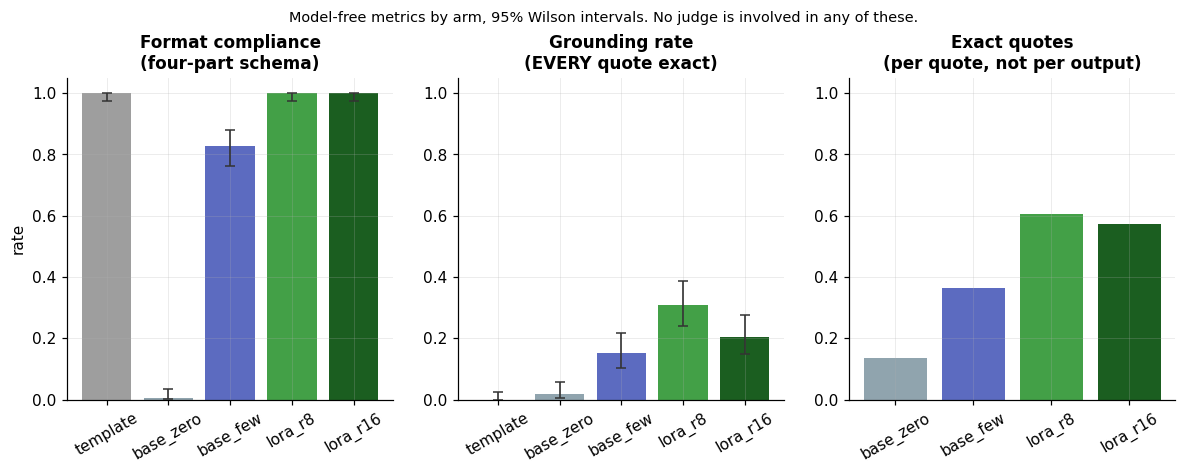

In [13]:
from src.plots import figures

figures.arm_metrics(summary)

### H1 and H2

Both are pre-registered as two-proportion z-tests, and both are **mechanical** —
no judge is involved. That is the point of the comparison to Gudibande et al.,
who reported style transferring and factuality not, judged by human raters at
7–13B. The question here is whether the same split appears at 0.5B with a
substring check in place of the raters.

Effect sizes and 95% CIs are reported beside every p-value. A null is "no
detected difference", never proof of equality.

In [14]:
lora = [a for a in config.ARMS if a.startswith("lora_")]

h1 = metrics.compare_to_baseline(summary, "format_rate", baseline="base_few",
                                 arms=lora, name="H1 format compliance")
h2 = metrics.compare_to_baseline(summary, "grounding_rate", baseline="base_few",
                                 arms=lora, name="H2 grounding rate")

results = metrics.adjust(h1 + h2)
display(metrics.to_frame(results))
for r in results:
    print(f"{r.name}\n    {r.verdict()}")

,test,judge,n,effect,effect_name,ci_low,ci_high,p_value,p_adjusted,verdict
0,H1 format compliance — lora_r8 vs base_few,,304,0.171053,difference in rate,0.111190,0.230915,9.706518e-08,3.882607e-07,detected difference (p=0.0000)
1,H1 format compliance — lora_r16 vs base_few,,304,0.171053,difference in rate,0.111190,0.230915,9.706518e-08,3.882607e-07,detected difference (p=0.0000)
2,H2 grounding rate — lora_r8 vs base_few,,304,0.157895,difference in rate,0.064923,0.250867,1.077098e-03,2.154196e-03,detected difference (p=0.0011)
3,H2 grounding rate — lora_r16 vs base_few,,304,0.052632,difference in rate,-0.033092,0.138356,2.299476e-01,2.299476e-01,no detected difference (p=0.2299)


H1 format compliance — lora_r8 vs base_few
    detected difference (p=0.0000)
H1 format compliance — lora_r16 vs base_few
    detected difference (p=0.0000)
H2 grounding rate — lora_r8 vs base_few
    detected difference (p=0.0011)
H2 grounding rate — lora_r16 vs base_few
    no detected difference (p=0.2299)


## The data-size curve

The three ablation adapters over the same 152 poems, read in grounding rate
rather than perplexity. This is the axis Zhou et al. (LIMA) speaks to: their
Superficial Alignment Hypothesis says a model's knowledge comes from pretraining
and fine-tuning mainly teaches which *format* to answer in, which is why a small
number of examples suffices.

That makes a prediction these two curves test directly — **format should
saturate fast, and grounding should not need to improve much.**

The confound to carry into the caption: the subsets are a sorted prefix of the
pool and `poem_id` clusters by author, so author coverage moves with data size.
It is printed alongside rather than left implicit.

In [15]:
runs = pd.read_csv(config.RESULTS_DIR / "runs.csv").set_index("run")
pool = sorted(splits.pool_partition(corpus), key=lambda p: p["poem_id"])

curve = metrics.model_free_summary(
    outputs, corpus, arms=list(config.ABLATION_ARMS) + ["lora_r8"])
curve["n_train"] = [runs.loc[a, "n_train"] for a in curve.arm]
curve["authors"] = [len({p["author"] for p in pool[:n]}) for n in
                    [200, 500, 1000, len(pool)]]
curve["heldout_perplexity"] = [runs.loc[a, "heldout_perplexity"] for a in curve.arm]

display(curve[["arm", "n_train", "authors", "format_rate", "grounding_rate",
               "exact_quote_rate", "quotes_per_interpretation",
               "heldout_perplexity"]])
curve.to_csv(config.RESULTS_DIR / "data_size_curve.csv", index=False)

INFO pool: 2384 of 2536 pairs (152 held out as test)


,arm,n_train,authors,format_rate,grounding_rate,exact_quote_rate,quotes_per_interpretation,heldout_perplexity
0,ablation_n200,177,13,1.0,0.144737,0.401891,2.782895,5.931021
1,ablation_n500,444,21,1.0,0.197368,0.542857,2.763158,5.520202
2,ablation_n1000,896,28,1.0,0.256579,0.560538,2.934211,5.292537
3,lora_r8,2128,85,1.0,0.309211,0.605442,2.901316,4.921104


The rank panel plots **every tuning fold**, not the mean. On a mean-only plot
the y-axis spans 0.008 of loss and a negligible rank effect renders as a steep
climb — the fold spread is several times the between-rank difference, and a
reader has to be able to see that. It is the comparison against Hu et al.'s
low-rank saturation finding.

INFO wrote /Users/adelinchaushev/Desktop/PoetryIntepretations./results/figures/10_saturation.png


PosixPath('/Users/adelinchaushev/Desktop/PoetryIntepretations./results/figures/10_saturation.png')

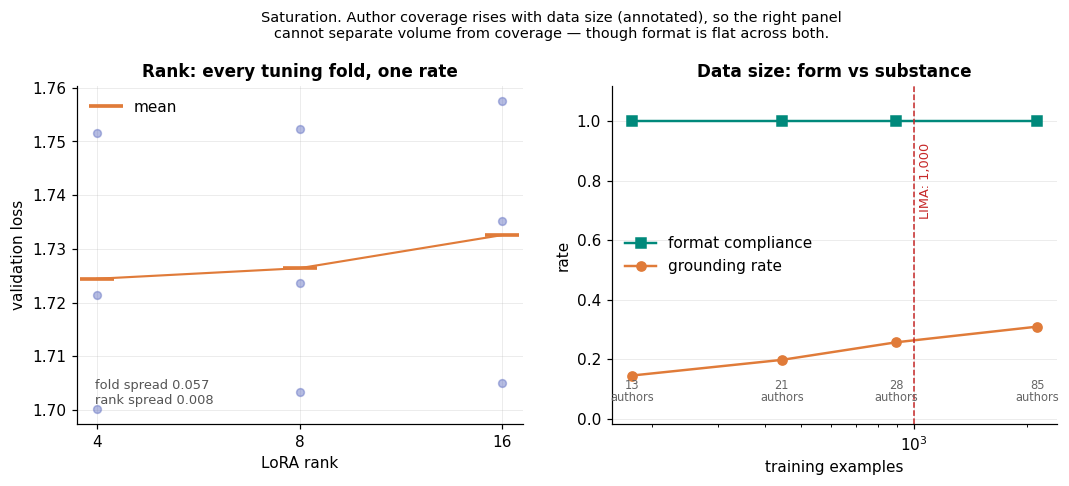

In [16]:
cv = pd.read_csv(config.RUNS_CSV_PATH)
cv = cv[cv.run.str.startswith("cv_") & (cv.learning_rate == config.LEARNING_RATE)]
rank_folds = cv.groupby("rank").final_val_loss.apply(list).to_dict()

figures.saturation(curve, rank_folds)

## The swap test

Each interpretation is scored against three poems: the one it was written for,
a random poem by a **different** author, and a different poem by the **same**
author. Two gaps follow — grounding gap (matched − random) and poem-level gap
(matched − same author) — and their difference is the author-level component of
apparent grounding.

The strict condition is the one that matters. An author's themes recur, so a
model that learned "Dickinson writes about death and immortality" can emit a
plausible interpretation for an unseen Dickinson poem *without reading it*, and
the standard control would score that as well grounded.

`check_all` runs the assertions before anything is paid for: no poem scored
against its own interpretation, `mismatched_random` always a different author,
`mismatched_same_author` always the same author and never the same poem, and no
near-duplicate drawn as the same-author control — PoetryDB publishes some poems
under several titles, and drawing one would silently turn the strict condition
into the matched condition.

In [17]:
duplicates = data_filter.near_duplicate_ids(corpus)

pairs = []
for arm in config.ARMS:
    arm_pairs = swap_test.build_pairs(
        [{"poem_id": r["poem_id"], "interpretation": r["interpretation"]}
         for r in outputs if r["arm"] == arm],
        corpus, arm=arm, near_duplicates=duplicates)
    swap_test.check_all(arm_pairs, corpus, near_duplicates=duplicates)
    pairs.extend(arm_pairs)

print(f"{len(pairs)} pairs = {len(config.ARMS)} arms x {len(test_ids)} poems "
      f"x {len(config.SWAP_CONDITIONS)} conditions")
print(f"{len(pairs) * len(config.JUDGES)} calls with both judges")

INFO built 456 pairs for arm 'template' (152 interpretations x 3 conditions)
INFO swap-test pair construction passed every structural check
INFO built 456 pairs for arm 'base_zero' (152 interpretations x 3 conditions)
INFO swap-test pair construction passed every structural check
INFO built 456 pairs for arm 'base_few' (152 interpretations x 3 conditions)
INFO swap-test pair construction passed every structural check
INFO built 456 pairs for arm 'lora_r8' (152 interpretations x 3 conditions)
INFO swap-test pair construction passed every structural check
INFO built 456 pairs for arm 'lora_r16' (152 interpretations x 3 conditions)
INFO swap-test pair construction passed every structural check


2280 pairs = 5 arms x 152 poems x 3 conditions
4560 calls with both judges


## Judge scoring

Both judges score everything. **Results are keyed by judge at every stage** —
in the cache file, in the aggregation, in every table — so the two can never be
silently pooled. Pooling is the failure that turns a robustness check into a
composite metric nobody can interpret.

GPT-4o-mini is the pre-registered primary and decides every headline number.
Gemini Flash re-runs each one as a robustness check and is reported beside it,
never averaged with it and never substituted for it.

Resumable: `score_all` skips any pair already cached, so a run interrupted
part-way continues rather than paying twice.

In [18]:
scored = {}
for spec in config.JUDGES:
    try:
        scored[spec.name] = judge.score_all(pairs, corpus, spec)
    except Exception as error:
        print(f"{spec.name}: {type(error).__name__}: {str(error)[:200]}")

for name, records in scored.items():
    usable = [r for r in records if r.get("score") is not None]
    print(f"{name:<14} {len(usable)}/{len(pairs)} scored, "
          f"{len(records) - len(usable)} unparseable")

INFO gpt4o_mini: 2280 cached, 0 to score
INFO gemini_flash: 2272 cached, 8 to score


gemini_flash:   0%|          | 0/8 [00:00<?, ?pair/s]

gpt4o_mini     2280/2280 scored, 0 unparseable
gemini_flash   2272/2280 scored, 8 unparseable


### Gaps by arm

Reported per judge, side by side, so a reader can see whether a conclusion
depends on which judge was asked. Where they disagree, that disagreement is
itself a finding about how much weight a single-judge evaluation deserves.

In [19]:
rows = []
for name, records in scored.items():
    for arm in config.ARMS:
        arm_records = [r for r in records if r.get("arm") == arm
                       and r.get("score") is not None]
        if arm_records:
            rows.append({"judge": name, "arm": arm, **judge.gaps(arm_records)})

gaps = pd.DataFrame(rows)
display(gaps)
gaps.to_csv(config.SWAP_SUMMARY_CSV_PATH, index=False)

,judge,arm,grounding_gap,poem_level_gap,author_component,n_pairs
0,gpt4o_mini,template,-0.013158,-0.006579,-0.006579,152
1,gpt4o_mini,base_zero,1.210526,1.032895,0.177632,152
2,gpt4o_mini,base_few,2.493421,2.203947,0.289474,152
3,gpt4o_mini,lora_r8,5.296053,5.118421,0.177632,152
4,gpt4o_mini,lora_r16,5.625000,5.407895,0.217105,152
5,gemini_flash,template,0.032895,-0.046053,0.078947,152
6,gemini_flash,base_zero,0.859060,0.863946,-0.004885,149
7,gemini_flash,base_few,1.822368,1.769737,0.052632,152
8,gemini_flash,lora_r8,4.440789,4.434211,0.006579,152
9,gemini_flash,lora_r16,5.085526,5.085526,0.000000,152
